# LSTM - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


## Tahap 1: Inisialisasi dan Impor Library

In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression  # Untuk Platt Scaling [AUDIT FIX]
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix,
    brier_score_loss, mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['lines.linewidth'] = 2.0

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...")


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger, ModelCheckpoint

# Fungsi utilitas untuk mengecek proporsi dataset secara terpisah
def print_dataset_distribution(title, X_tr, y_tr, X_va, y_va, X_te, y_te):
    n_train = len(X_tr)
    n_val = len(X_va)
    n_test = len(X_te)
    total = n_train + n_val + n_test
    
    y_tr_np = np.array(y_tr)
    y_va_np = np.array(y_va)
    y_te_np = np.array(y_te)
    
    rain = int(np.sum(y_tr_np == 1) + np.sum(y_va_np == 1) + np.sum(y_te_np == 1))
    non_rain = int(np.sum(y_tr_np == 0) + np.sum(y_va_np == 0) + np.sum(y_te_np == 0))
    
    rain_pct = (rain / total) * 100 if total > 0 else 0
    non_rain_pct = (non_rain / total) * 100 if total > 0 else 0
    pos_neg_ratio = rain / (non_rain + 1e-9)
    
    print("==============================")
    print(f"Dataset Distribution ({title})")
    print("==============================")
    print(f"Training samples: {n_train}")
    print(f"Validation samples: {n_val}")
    print(f"Testing samples: {n_test}")
    print(f"Rain samples: {rain}")
    print(f"Non-rain samples: {non_rain}")
    print(f"Rain percentage: {rain_pct:.2f}%")
    print(f"Non-rain percentage: {non_rain_pct:.2f}%")
    print(f"Positive/Negative ratio: {pos_neg_ratio:.4f}")
    print("=" * 30)

def cek_proporsi_pretraining(X_tr, y_tr, X_va, y_va, X_te, y_te):
    print_dataset_distribution("Pretraining", X_tr, y_tr, X_va, y_va, X_te, y_te)

def cek_proporsi_finetuning(X_tr, y_tr, X_va, y_va, X_te, y_te):
    print_dataset_distribution("Fine-Tuning", X_tr, y_tr, X_va, y_va, X_te, y_te)


2026-07-18 17:32:24,014 - INFO - Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...
2026-07-18 17:32:25.565218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784395945.741143      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784395945.791569      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784395946.238277      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784395946.238322      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than onc

## Tahap 2: Konfigurasi Global & Konstanta

In [2]:
# Sel 2: Konfigurasi Global
# File ini mendefinisikan konstanta fisik, rentang waktu pre-training, dan parameter HPO LSTM.
# Seluruh pengaturan bias correction telah dinonaktifkan/dihapus agar model fokus pada machine learning murni.
RUN_MODE = "FULL_TRAIN"  # "FULL_TRAIN" untuk latihan penuh, "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS    = 5
    EPOCHS_HPO       = 2   # Epoch per trial Optuna (singkat agar eksplorasi cepat)
    EPOCHS_BEST      = 2   # Epoch training model terbaik (lebih panjang, biarkan EarlyStopping bekerja)
    EPOCHS_FINETUNE  = 2   # Epoch fine-tuning pada data AWS
else:
    OPTUNA_TRIALS    = 50  # Jumlah trial optimasi hyperparameter dengan Optuna
    EPOCHS_HPO       = 30  # Epoch per trial Optuna — singkat, eksplorasi cepat, EarlyStopping handle sisanya
    EPOCHS_BEST      = 60 # Epoch training model terbaik — biarkan EarlyStopping + ReduceLR konvergensi penuh
    EPOCHS_FINETUNE  = 60  # Epoch fine-tuning — lebih konservatif agar tidak overfit data AWS

# Panjang urutan waktu (sequence) ke belakang untuk LSTM
LOOKBACK = 24

# Direktori output model dan visualisasi
from pathlib import Path
BASE_OUTPUT_DIR = Path('outputs_lstm')

# Batas ambang curah hujan untuk klasifikasi hujan/tidak hujan (mm/jam)
RAIN_THRESHOLD = 0.2

# Rentang tanggal pre-training menggunakan data satelit & ERA5
PRETRAIN__TRAIN_START = '2005-01-01'
PRETRAIN__TRAIN_END   = '2020-12-31'
PRETRAIN__VAL_START   = '2021-01-01'
PRETRAIN__VAL_END     = '2023-12-31'
PRETRAIN__TEST_START  = '2024-01-01'
PRETRAIN__TEST_END    = '2025-12-31'

# Batas tanggal fine-tuning menggunakan data aktual stasiun AWS bumi
FINETUNE_TRAIN_START = '2025-01-01'
FINETUNE_TRAIN_END   = '2026-01-15'
FINETUNE_VAL_START   = '2026-01-16'
FINETUNE_VAL_END     = '2026-04-05'
FINETUNE_TEST_START  = '2026-04-06'
FINETUNE_TEST_END    = '2026-05-31'

# Pemetaan fitur dari kolom mentah dataset ERA5 ke nama variabel meteorologi standar
ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate',
    'sealevel_pressure_era5': 'pressure',
    'u10_era5': 'era5_u_wind',
    'v10_era5': 'era5_v_wind',
    'cloud_cover_era5': 'era5_cloud_cover',
    'cape_era5': 'era5_cape',
    'total_column_water_vapour_era5': 'era5_tcwv',
    'moisture_divergence_era5': 'era5_moisture_div',
    'direct_radiation_era5': 'era5_direct_rad',
    'sunshine_duration_era5': 'era5_sunshine'
}


## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

## FASE 1: PRE-TRAINING (Data Satelit & ERA5)

In [4]:
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)
# Menggabungkan data historis cuaca ERA5 dengan target curah hujan satelit GSMaP untuk pre-training.
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)

import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Loading ERA5 + GSMaP dataset...")

# =============================================================================
# PATH
# =============================================================================
if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
    SAT_DIR = Path(search_file[0]).parent if search_file else Path('/kaggle/input/datasets/jerismeteo/google-earth-engine-data')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# =============================================================================
# LOAD ERA5
# =============================================================================
df_era5 = pd.read_csv(SAT_DIR / "ERA5_Hourly_All_Requested_Features_2000_2026.csv")

if "datetime_utc" in df_era5.columns:
    df_era5["timestamp"] = pd.to_datetime(df_era5["datetime_utc"], utc=True)
else:
    df_era5["timestamp"] = pd.to_datetime(df_era5["unixtime"], unit="s", utc=True)

df_era5 = df_era5.set_index("timestamp").sort_index()

# =============================================================================
# LOAD GSMAP (Hourly)
# =============================================================================
df_gsmap = pd.read_csv(SAT_DIR / "Rainfall_GSMap_TimeSeries_UNIX.csv")

if "datetime_utc" in df_gsmap.columns:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["datetime_utc"], utc=True)
else:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["unixtime"], unit="s", utc=True)

df_gsmap = df_gsmap.set_index("timestamp").sort_index()

# =============================================================================
# RESAMPLE GSMAP & ALIGN TO HOURLY (Rename column to mimic precipitation)
# =============================================================================
logger.info("Resampling GSMaP to hourly rainfall...")

df_gsmap_hourly = (
    df_gsmap[["hourlyPrecipRateGC"]]
    .rename(columns={"hourlyPrecipRateGC": "precipitation"})
)

# =============================================================================
# MERGE
# =============================================================================
df_merged = df_era5.merge(
    df_gsmap_hourly,
    left_index=True,
    right_index=True,
    how="left"
)

# =============================================================================
# FEATURE MAPPING
# =============================================================================
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_merged.columns:
        df_merged[new_name] = df_merged[raw_col]

# =============================================================================
# REPLACE ERA5 RAIN WITH IMERG
# =============================================================================
if "rainrate" in df_merged.columns and "precipitation" in df_merged.columns:
    logger.info("Replacing ERA5 rainfall using GSMaP...")
    df_merged["rainrate"] = df_merged["precipitation"].combine_first(df_merged["rainrate"])

# =============================================================================
# REMOVE DRIZZLE
# =============================================================================
if "rainrate" in df_merged.columns:
    df_merged["rainrate"] = np.where(df_merged["rainrate"] >= 0.2, df_merged["rainrate"], 0.0)

# =============================================================================
# KEEP REQUIRED FEATURES
# =============================================================================
selected_features = [v for v in ERA5_FEATURES_MAPPING.values() if v in df_merged.columns]
df_merged = df_merged[selected_features]

# =============================================================================
# CLEAN DATA
# =============================================================================
if "temperature" in df_merged.columns:
    df_hourly = df_merged.dropna(subset=["temperature"]).copy()
else:
    df_hourly = df_merged.dropna().copy()

df_hourly = df_hourly.select_dtypes(include=[np.number])



2026-07-18 17:32:37,181 - INFO - Loading ERA5 + GSMaP dataset...
2026-07-18 17:32:41,485 - INFO - Resampling GSMaP to hourly rainfall...
2026-07-18 17:32:41,521 - INFO - Replacing ERA5 rainfall using GSMaP...


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

## Tahap 4.5: Persiapan Parameter LSTM

## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna LSTM)

## Tahap 6: Pelatihan Regresi Intensitas (Optuna LSTM)

## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

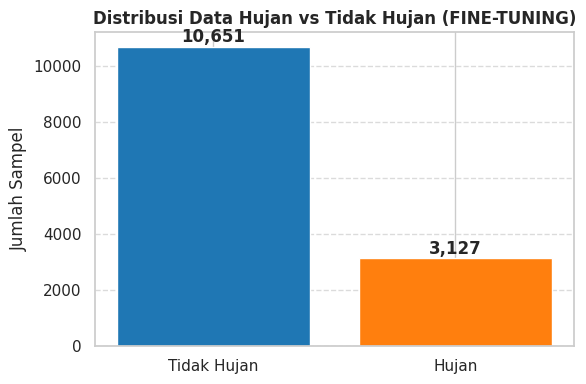

In [11]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (FINE-TUNING)
# Memantau proporsi kejadian hujan stasiun bumi AWS pada data fine-tuning.
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Hujan vs Tidak Hujan (FINE-TUNING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

## Tahap 4.75: Pembentukan Sekuens Data Waktu

Mengubah data tabular (2D) menjadi format sekuens (3D) `[samples, timesteps, features]` yang disyaratkan oleh arsitektur LSTM.

## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model (LSTM)

Di tahap ini, bobot dari model LSTM global digunakan sebagai basis (Pre-trained) dan di-*retrain* secara hati-hati menggunakan dataset lokal (AWS). Laporan komparasi performa akan dicetak secara otomatis.

In [14]:
# Sel 13: Proses Fine-Tuning (LSTM)
# Melatih ulang model dasar (Classifier & Regressor LSTM) secara warm-start menggunakan data stasiun AWS,
# menyetel ulang kalibrator optimal pada data validasi fine-tuning.
import joblib
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. LOAD MODEL TERBAIK PRE-TRAINING (diperlukan untuk fine-tuning)
logger.info("Memuat model terbaik pre-training...")
clf_best = tf.keras.models.load_model(evaluator.dirs['models_clf'] / 'best_lstm_occ.keras')
reg_best = None
if (evaluator.dirs['models_reg'] / 'best_lstm_reg.keras').exists():
    reg_best = tf.keras.models.load_model(evaluator.dirs['models_reg'] / 'best_lstm_reg.keras')

# 2. PROSES FINE-TUNING CLASSIFIER (Learning Rate = 0.01)
logger.info("Memulai Fine-Tuning LSTM Classifier...")
clf_best.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

batch_size_ft = 64
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset
    .from_tensor_slices((X_tr_seq, y_tr_o))
    .shuffle(buffer_size=len(X_tr_seq), seed=SEED)
    .batch(batch_size_ft)
    .cache()
    .prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset
    .from_tensor_slices((X_v_seq, y_v_o))
    .batch(batch_size_ft)
    .cache()
    .prefetch(AUTOTUNE))

clf_ft_ckpt = str(evaluator.dirs['models_clf'] / 'best_lstm_occ_finetuned_ckpt.keras')
es      = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
ckpt_ft = ModelCheckpoint(clf_ft_ckpt, monitor='val_loss', save_best_only=True, verbose=0)

history_clf_ft = clf_best.fit(train_ds, validation_data=val_ds,
                               epochs=EPOCHS_FINETUNE, callbacks=[es, ckpt_ft], verbose=1)
clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ_finetuned.keras')

# Kalibrasi ulang menggunakan data validasi fine-tuning
val_probs_uncal = clf_best.predict(X_v_seq, verbose=0).flatten()
iso_reg, cal_method_ft = fit_best_calibrator(y_v_o, val_probs_uncal)
if iso_reg is not None:
    joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator_finetuned.pkl')

# Dynamic threshold search pada data validasi fine-tuning
val_probs_cal_ft = apply_calibrator(iso_reg, cal_method_ft, val_probs_uncal) if iso_reg is not None else val_probs_uncal
best_threshold_finetuned, best_f1_ft = 0.5, 0.0
for _t in np.arange(0.20, 0.70, 0.02):
    _preds = (val_probs_cal_ft >= _t).astype(int)
    _f1 = f1_score(y_v_o, _preds, zero_division=0)
    if _f1 > best_f1_ft:
        best_f1_ft, best_threshold_finetuned = _f1, float(_t)
joblib.dump(best_threshold_finetuned, evaluator.dirs['models_clf'] / 'best_threshold_finetuned.pkl')
logger.info(f"Optimal Classification Threshold (Fine-Tuning): {best_threshold_finetuned:.2f} (F1={best_f1_ft:.4f})")

rainy_tr = y_tr_o == 1
rainy_v  = y_v_o  == 1

if np.sum(rainy_tr) > 10 and reg_best is not None:
    logger.info("Memulai Fine-Tuning Regressor...")
    X_tr_r_val = X_tr_seq[rainy_tr]
    y_tr_r_val = np.log1p(y_tr_r[rainy_tr])
    X_v_r_val  = X_v_seq[rainy_v]
    y_v_r_val  = np.log1p(y_v_r[rainy_v])

    reg_best.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

    train_reg_ds = (tf.data.Dataset
        .from_tensor_slices((X_tr_r_val, y_tr_r_val))
        .shuffle(buffer_size=len(X_tr_r_val), seed=SEED)
        .batch(batch_size_ft)
        .cache()
        .prefetch(AUTOTUNE))
    val_reg_ds = (tf.data.Dataset
        .from_tensor_slices((X_v_r_val, y_v_r_val))
        .batch(batch_size_ft)
        .cache()
        .prefetch(AUTOTUNE))

    reg_ft_ckpt = str(evaluator.dirs['models_reg'] / 'best_lstm_reg_finetuned_ckpt.keras')
    es_reg      = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    ckpt_reg_ft = ModelCheckpoint(reg_ft_ckpt, monitor='val_loss', save_best_only=True, verbose=0)

    history_reg_ft = reg_best.fit(train_reg_ds, validation_data=val_reg_ds,
                                   epochs=EPOCHS_FINETUNE, callbacks=[es_reg, ckpt_reg_ft], verbose=1)
    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg_finetuned.keras')

logger.info("Fine-Tuning LSTM Selesai!")


2026-07-18 22:23:40,890 - INFO - Memuat model terbaik pre-training...
2026-07-18 22:23:41,134 - INFO - Memulai Fine-Tuning LSTM Classifier...


Epoch 1/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2908 - precision: 0.7620 - recall: 0.4924 - val_loss: 0.5540 - val_precision: 0.6356 - val_recall: 0.5644
Epoch 2/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2666 - precision: 0.7854 - recall: 0.5405 - val_loss: 0.5800 - val_precision: 0.6546 - val_recall: 0.3896
Epoch 3/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2527 - precision: 0.7957 - recall: 0.5804 - val_loss: 0.5746 - val_precision: 0.6593 - val_recall: 0.3650
Epoch 4/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2474 - precision: 0.8119 - recall: 0.5900 - val_loss: 0.6164 - val_precision: 0.7014 - val_recall: 0.2991
Epoch 5/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2421 - precision: 0.7998 - recall: 0.5790 - val_loss: 0.5967 - val_precision: 0.6442 - val_recall: 0.3666
Epoch 6/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2438 - precision: 0.8136 - recall: 0.5817 - val_loss: 0.5612 - val_precision: 0.6744 - val_recall

2026-07-18 22:23:54,563 - INFO - [Calibrator Selection] Brier scores - Raw: 0.1843, Platt: 0.1804, Isotonic: 0.1736
2026-07-18 22:23:54,564 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-18 22:23:54,628 - INFO - Optimal Classification Threshold (Fine-Tuning): 0.32 (F1=0.6410)
2026-07-18 22:23:54,629 - INFO - Memulai Fine-Tuning Regressor...


Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3963 - val_loss: 0.2572
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3483 - val_loss: 0.2557
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3342 - val_loss: 0.2757
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3285 - val_loss: 0.2523
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3279 - val_loss: 0.2595
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3198 - val_loss: 0.2605
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3227 - val_loss: 0.2751
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3150 - val_loss: 0.2726
Epoch 9/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3314 - val_loss: 0.2757
Epoch 10/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3517 - val_loss: 0.2911
Epoch 11/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3587 - val_loss: 0.2609
Epoch 12/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3443 - val

2026-07-18 22:23:58,923 - INFO - Fine-Tuning LSTM Selesai!


# Bab 1: Evaluasi Model Pretraining
Dalam bab ini, model dasar LSTM yang dilatih hanya menggunakan data satelit (Pre-Trained) dievaluasi kinerjanya pada data uji sekuensial stasiun AWS bumi untuk melihat tingkat akurasi awal sebelum penyesuaian lokal.


2026-07-18 22:23:59,978 - INFO - Memulai Bab 1: Evaluasi Model Pretraining...
2026-07-18 22:24:00,177 - INFO - Threshold klasifikasi pre-training: 0.68
2026-07-18 22:24:02,826 - INFO - Menghitung metrik klasifikasi...


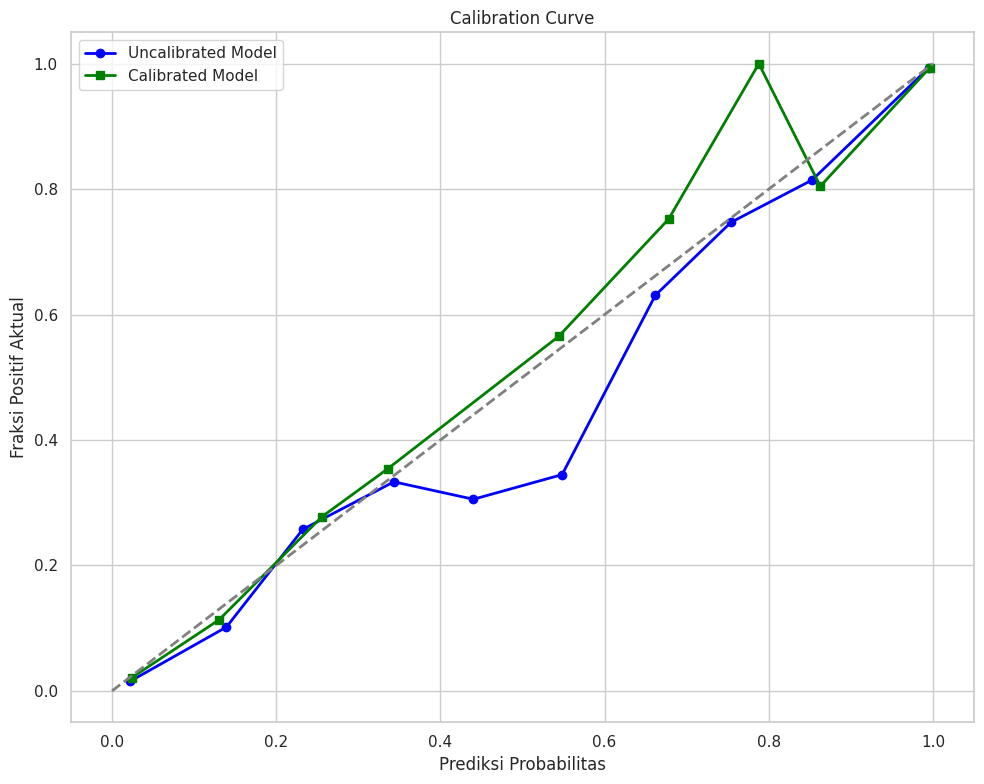

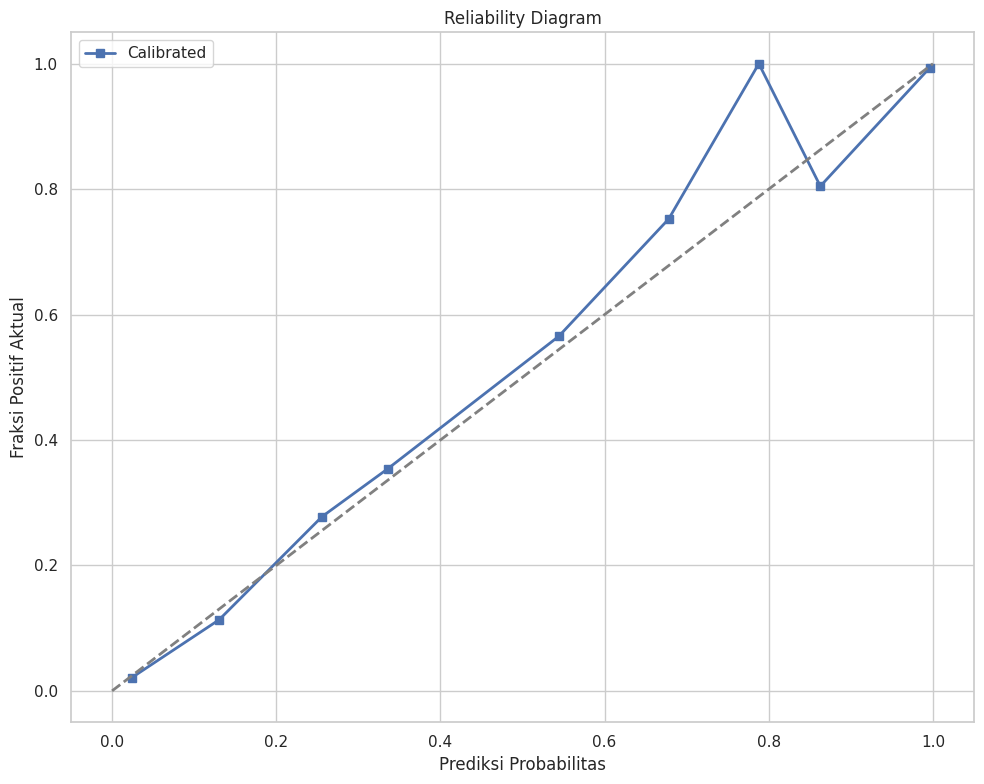

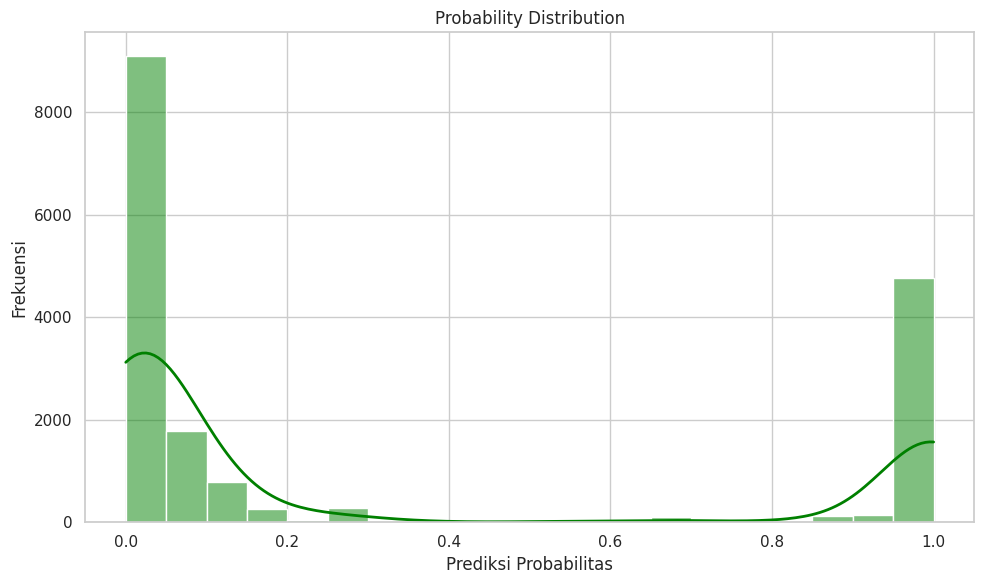

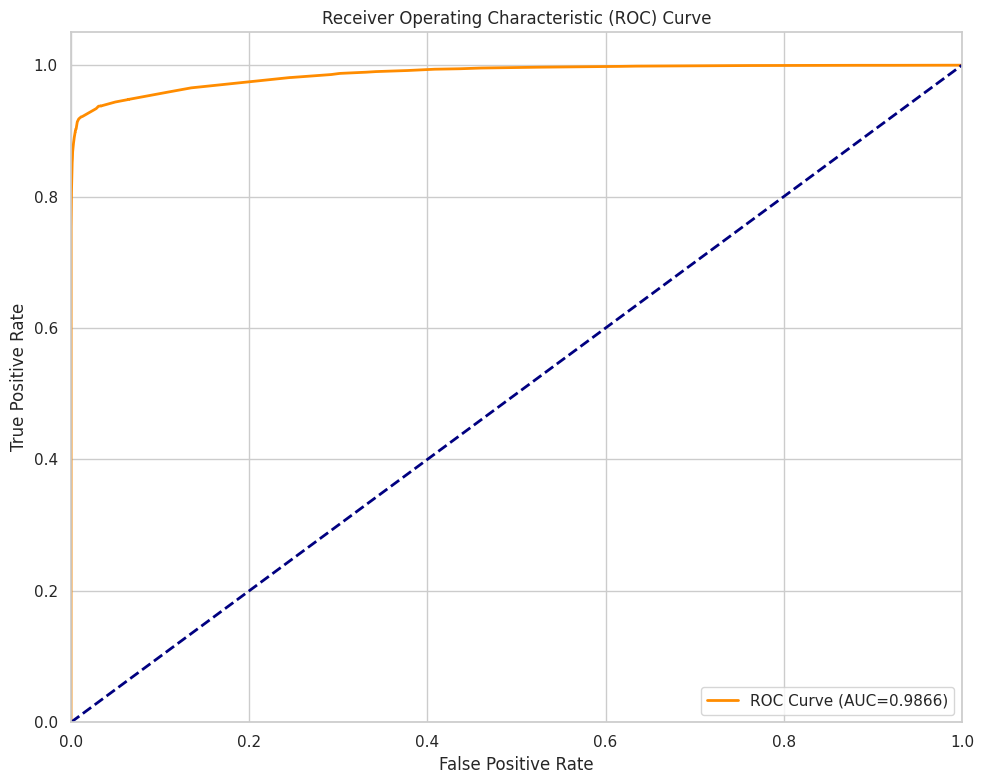

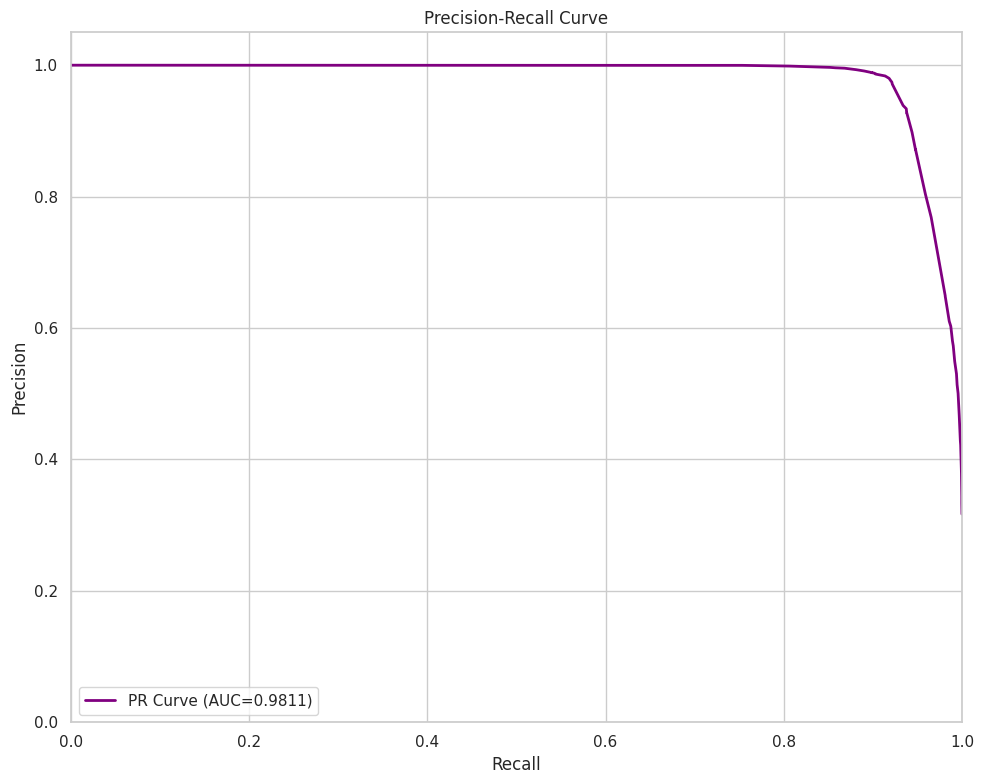

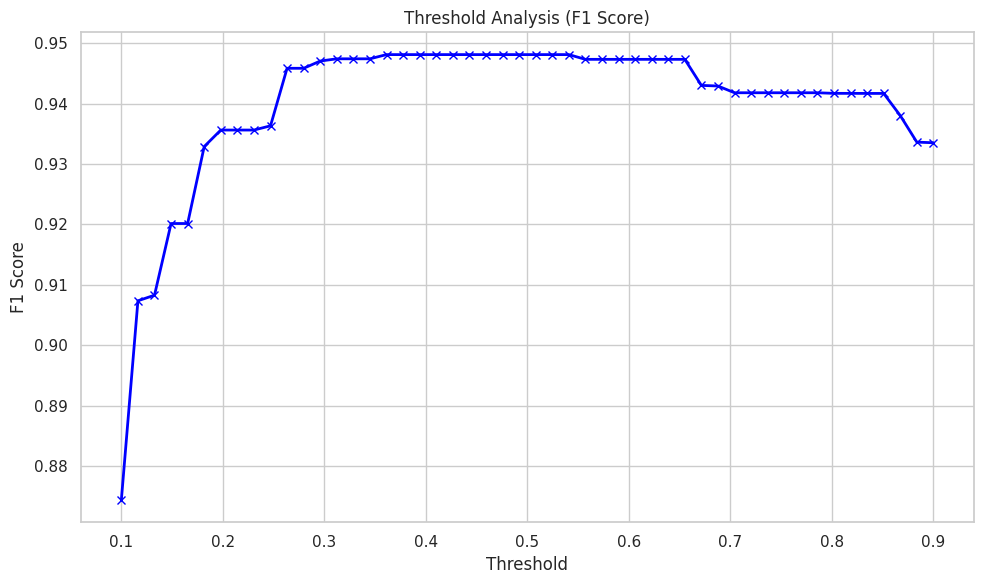

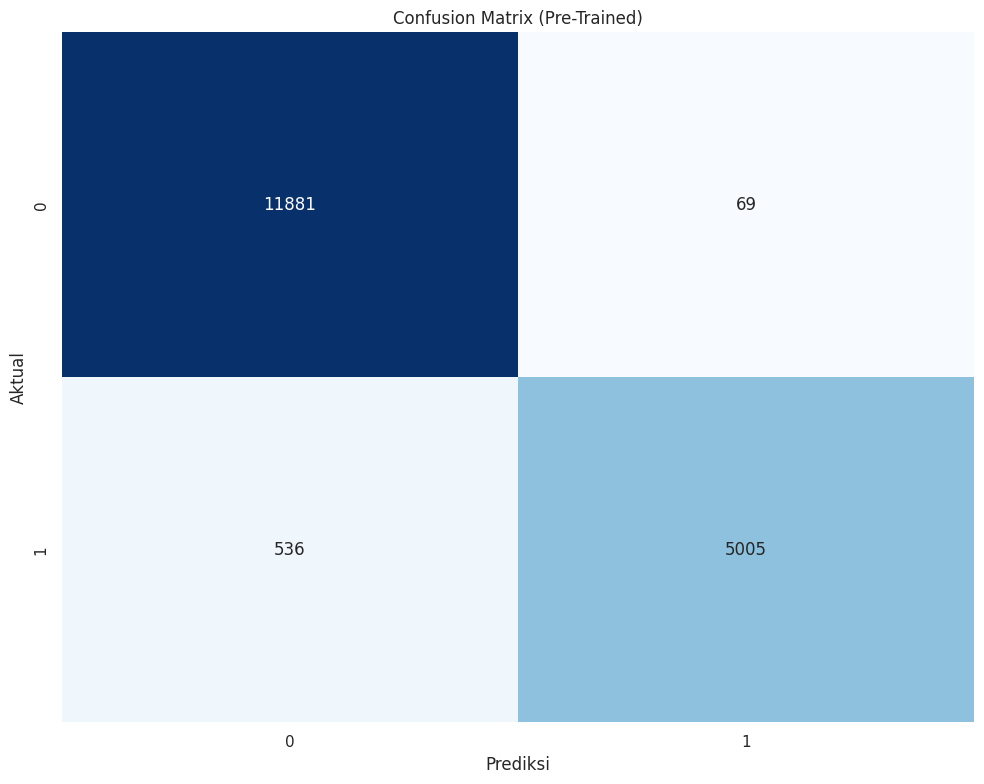

2026-07-18 22:24:07,318 - INFO - Menghitung metrik regresi...


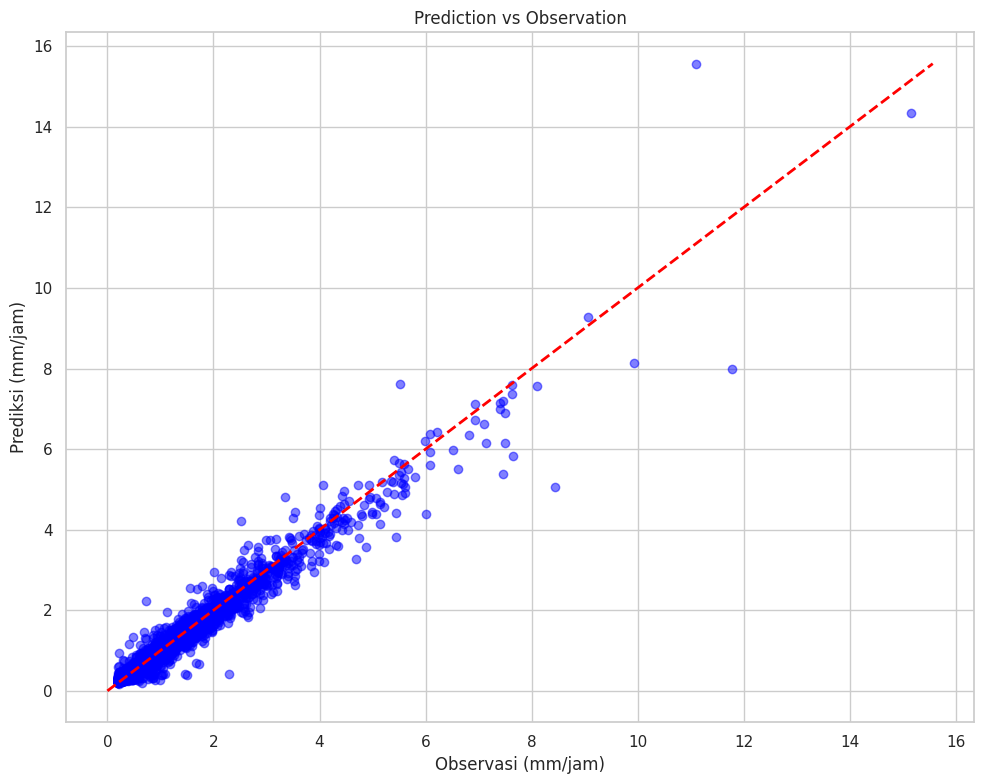

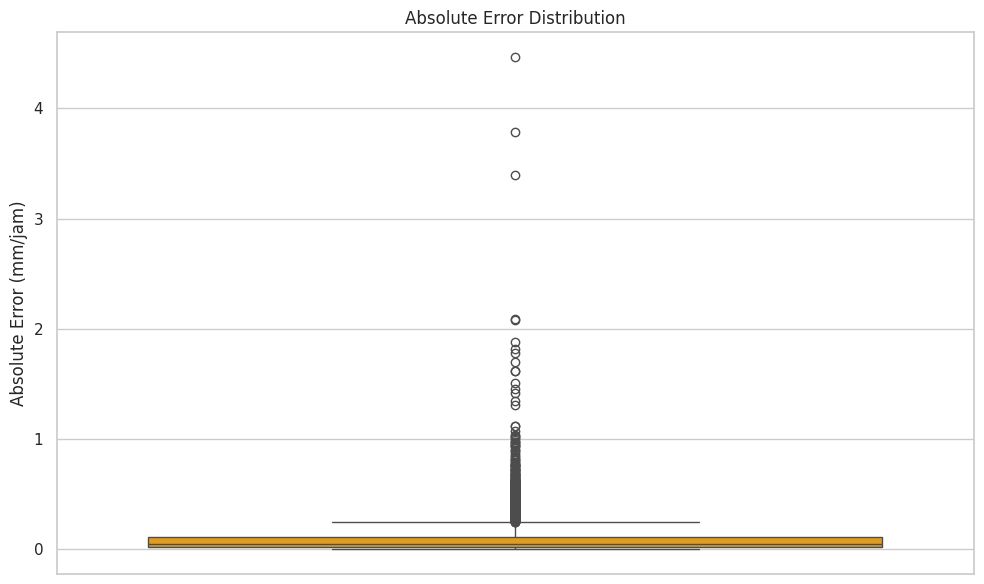

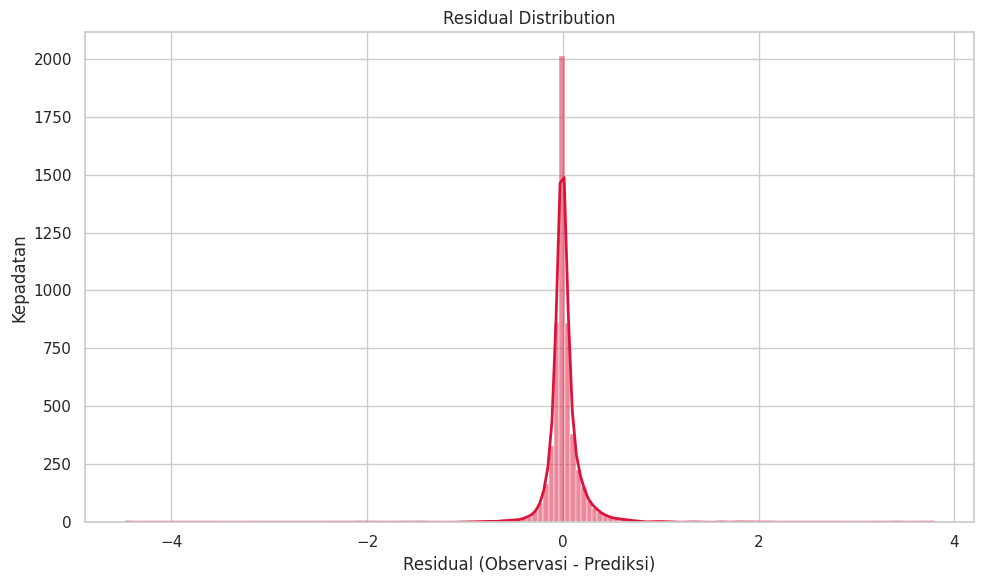

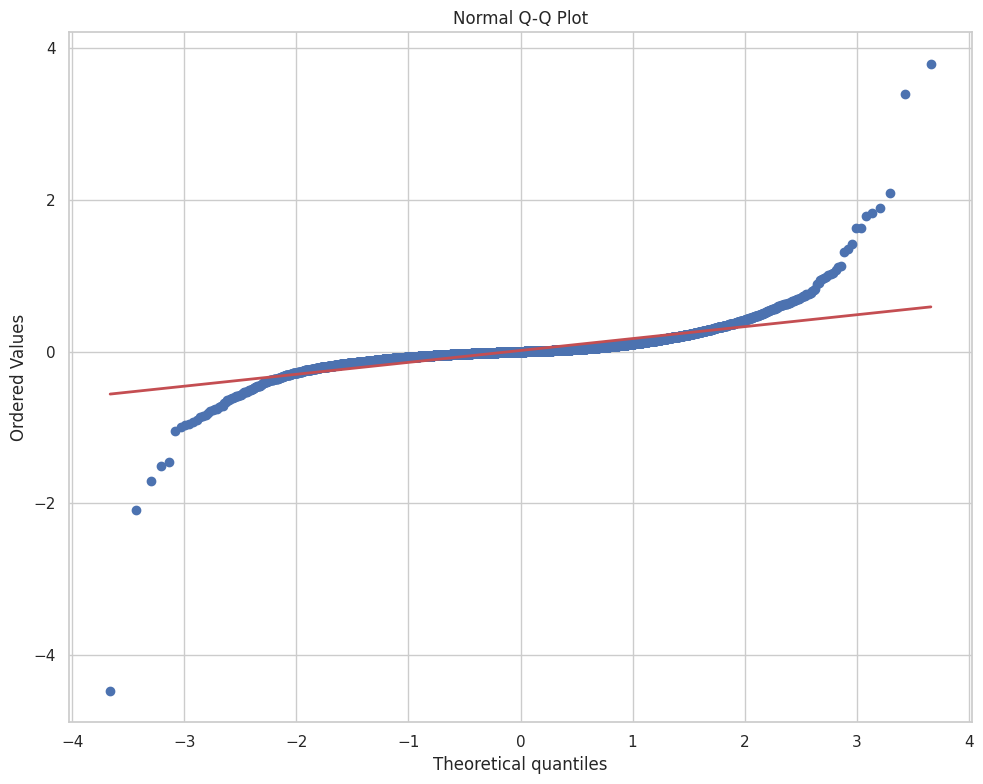

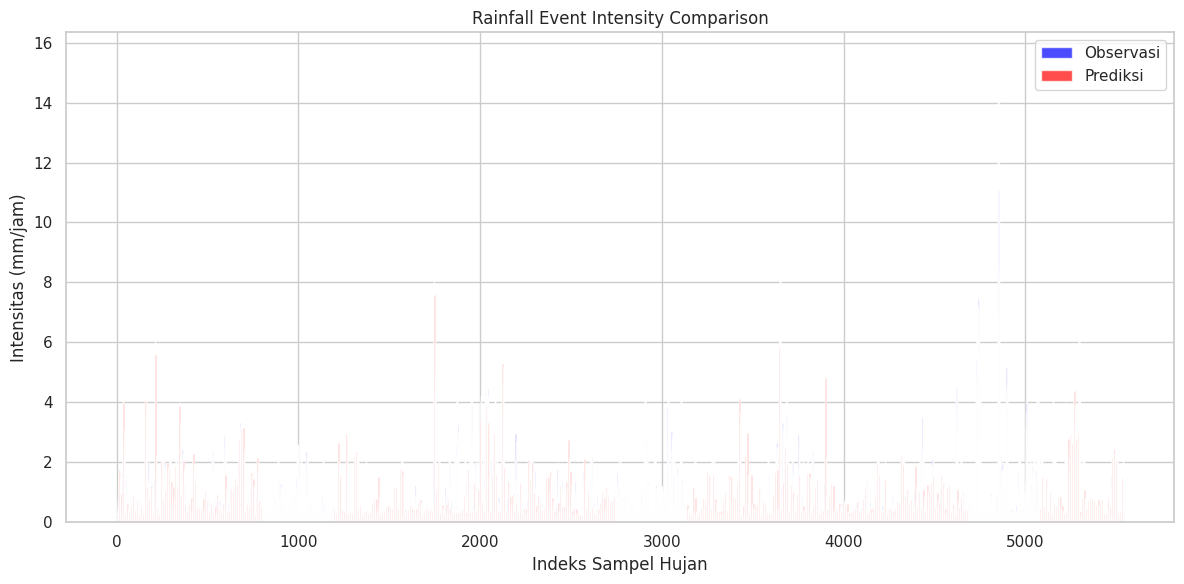

2026-07-18 22:24:30,061 - INFO - Evaluasi Model Pre-Trained Selesai!


In [15]:
# Bab 1: Evaluasi Model Pretraining (LSTM)
logger.info("Memulai Bab 1: Evaluasi Model Pretraining...")
evaluator_pre = ModelEvaluator(BASE_OUTPUT_DIR, phase='pretraining')

# Load model pre-trained asli (satelit)
clf_pretrain = tf.keras.models.load_model(evaluator_pre.dirs['models_clf'] / 'best_lstm_occ.keras')
reg_pretrain = tf.keras.models.load_model(evaluator_pre.dirs['models_reg'] / 'best_lstm_reg.keras') if (evaluator_pre.dirs['models_reg'] / 'best_lstm_reg.keras').exists() else None

# Pemuatan calibrator pre-train
calibrator_pre = joblib.load(evaluator_pre.dirs['models_cal'] / 'isotonic_calibrator.pkl')
cal_meta_pre = joblib.load(evaluator_pre.dirs['models_cal'] / 'calibration_meta.pkl')
cal_method_pre = cal_meta_pre['method']

# Load threshold optimal pre-training
_thresh_file_pre = evaluator_pre.dirs['models_clf'] / 'best_threshold_pretrain.pkl'
best_threshold_pretrain = joblib.load(_thresh_file_pre) if _thresh_file_pre.exists() else 0.5
logger.info(f"Threshold klasifikasi pre-training: {best_threshold_pretrain:.2f}")

# Prediksi Klasifikasi pada data uji satelit pre-training
pre_test_prob_uncal = clf_pretrain.predict(X_te_seq_pre, verbose=0).flatten()
pre_test_prob_cal = apply_calibrator(calibrator_pre, cal_method_pre, pre_test_prob_uncal)
pre_test_preds = (pre_test_prob_cal >= best_threshold_pretrain).astype(int)

# Prediksi Regresi (Hanya pada sampel hujan)
pre_test_preds_r_pre = np.zeros(len(y_te_o_pre))
rainy_te_pre = y_te_o_pre == 1
if reg_pretrain is not None and np.sum(rainy_te_pre) > 0:
    pre_test_preds_r_pre[rainy_te_pre] = np.clip(np.expm1(reg_pretrain.predict(X_te_seq_pre[rainy_te_pre], verbose=0).flatten()), 0, None)

# Jalankan Evaluasi Klasifikasi Pre-Trained
clf_metrics_pre, meteo_metrics_pre = evaluator_pre.evaluate_classification(
    y_te_o_pre, pre_test_prob_uncal, pre_test_prob_cal, pre_test_preds
)
ece_pre, mce_pre = compute_ece_mce(y_te_o_pre, pre_test_prob_cal)
clf_metrics_pre['ECE'] = ece_pre
clf_metrics_pre['MCE'] = mce_pre
evaluator_pre.save_combined_metrics()

# Simpan Confusion Matrix Pre-Trained
evaluator_pre.plot_confusion_matrix(y_te_o_pre, pre_test_preds, filename='confusion_matrix.png', suffix='(Pre-Trained)')

# Jalankan Evaluasi Regresi Pre-Trained
if np.sum(rainy_te_pre) > 0:
    reg_metrics_pre = evaluator_pre.evaluate_regression(y_te_r_pre[rainy_te_pre], pre_test_preds_r_pre[rainy_te_pre])
else:
    reg_metrics_pre = {}

# Buat Laporan Evaluasi Pre-Trained
evaluator_pre.generate_report(len(X_tr_seq), len(X_v_seq), len(X_te_seq_pre), list(scaler.feature_names_in_), clf_metrics_pre, meteo_metrics_pre, reg_metrics_pre, "LSTM (Pre-Trained)")
logger.info("Evaluasi Model Pre-Trained Selesai!")


# Bab 2: Evaluasi Model Fine-Tuning
Dalam bab ini, model LSTM yang telah disetel ulang (*Fine-Tuned*) secara *warm-start* menggunakan data stasiun bumi AWS dievaluasi kinerjanya pada data uji sekuensial AWS Bumi.


2026-07-18 22:24:31,497 - INFO - Memulai Bab 2: Evaluasi Model Fine-Tuning...
2026-07-18 22:24:31,697 - INFO - Threshold klasifikasi fine-tuning: 0.32
2026-07-18 22:24:32,463 - INFO - Menghitung metrik klasifikasi...


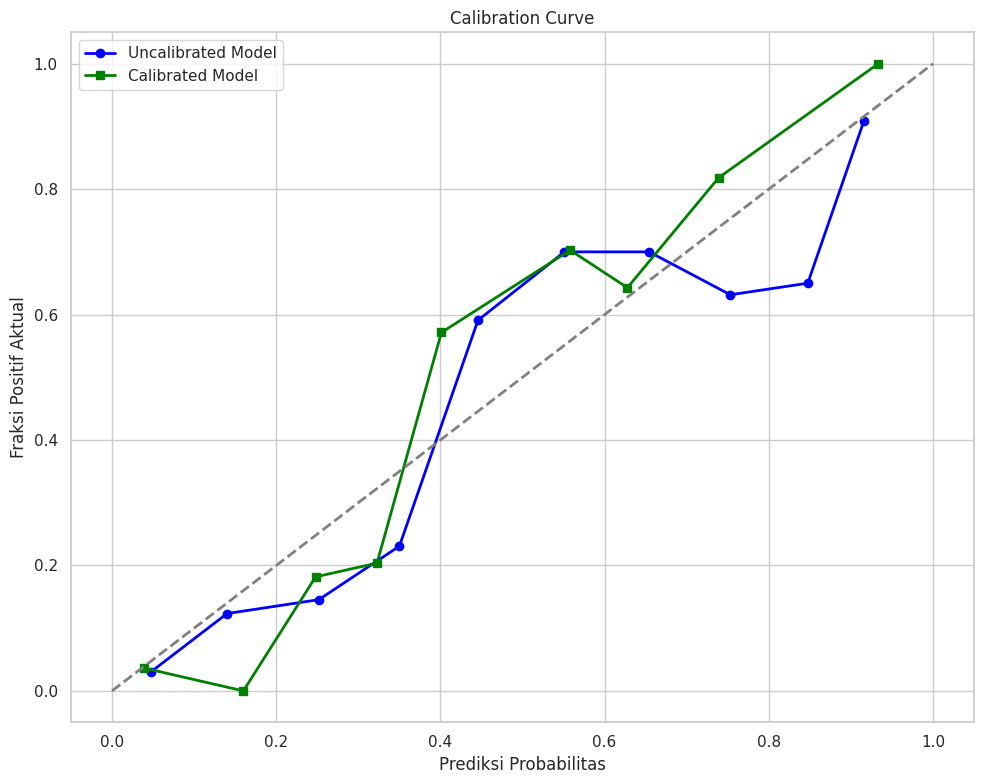

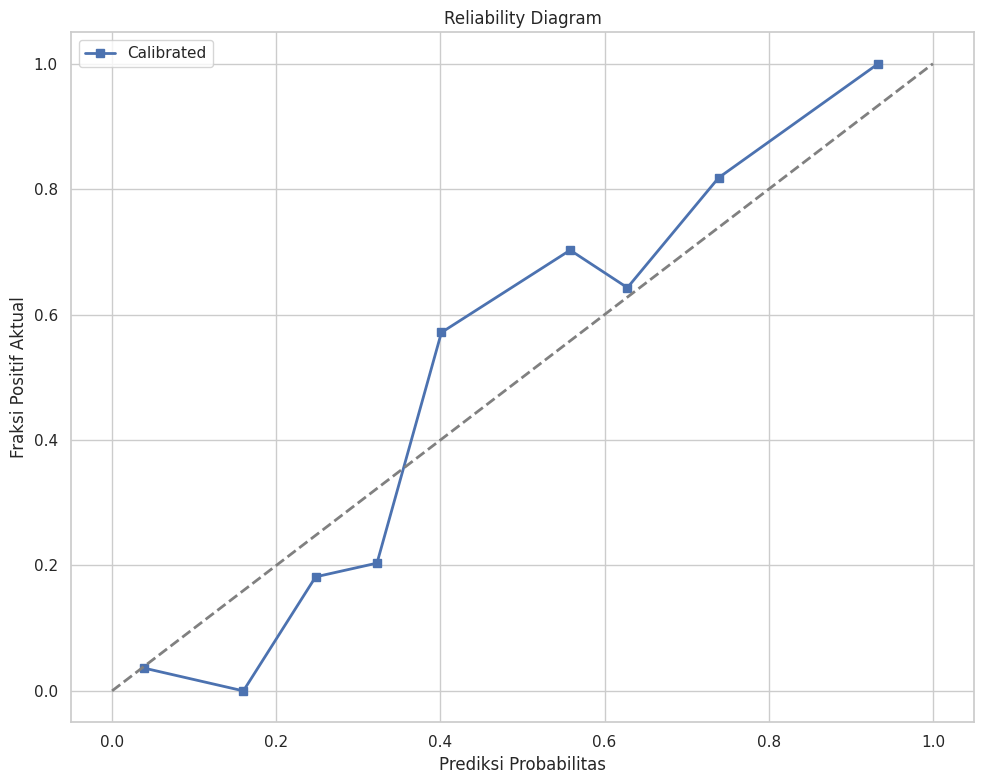

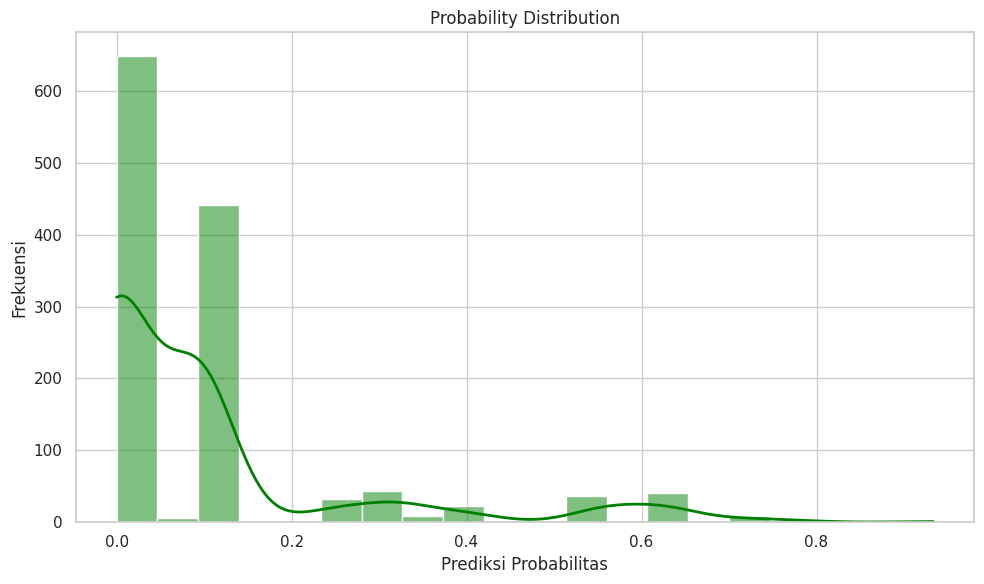

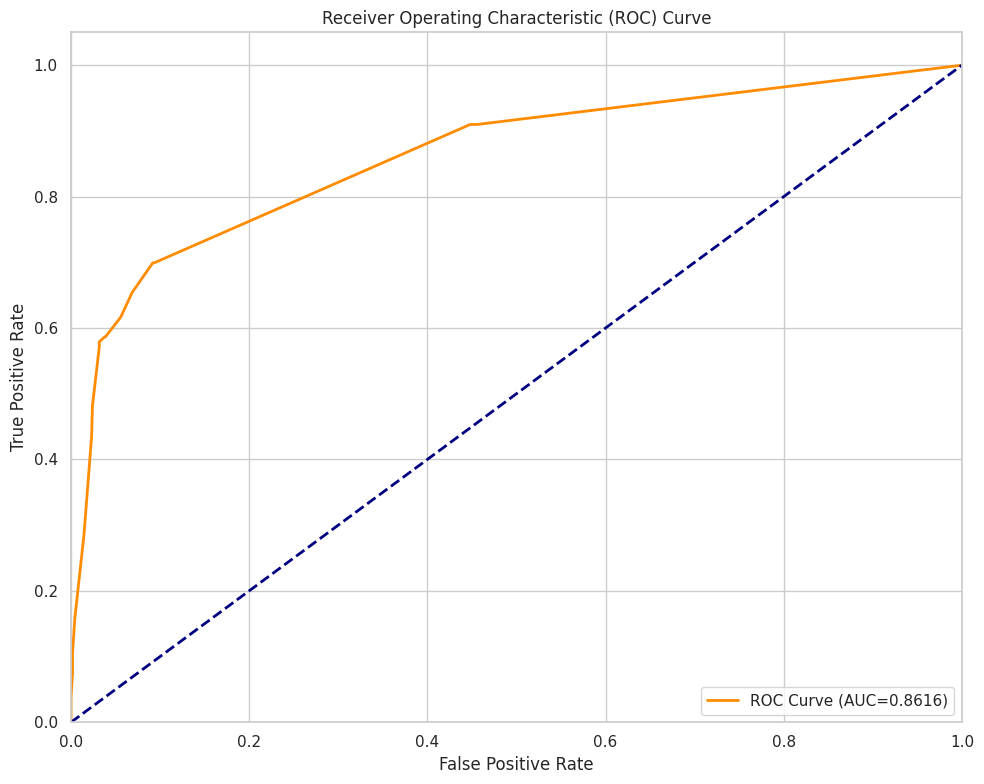

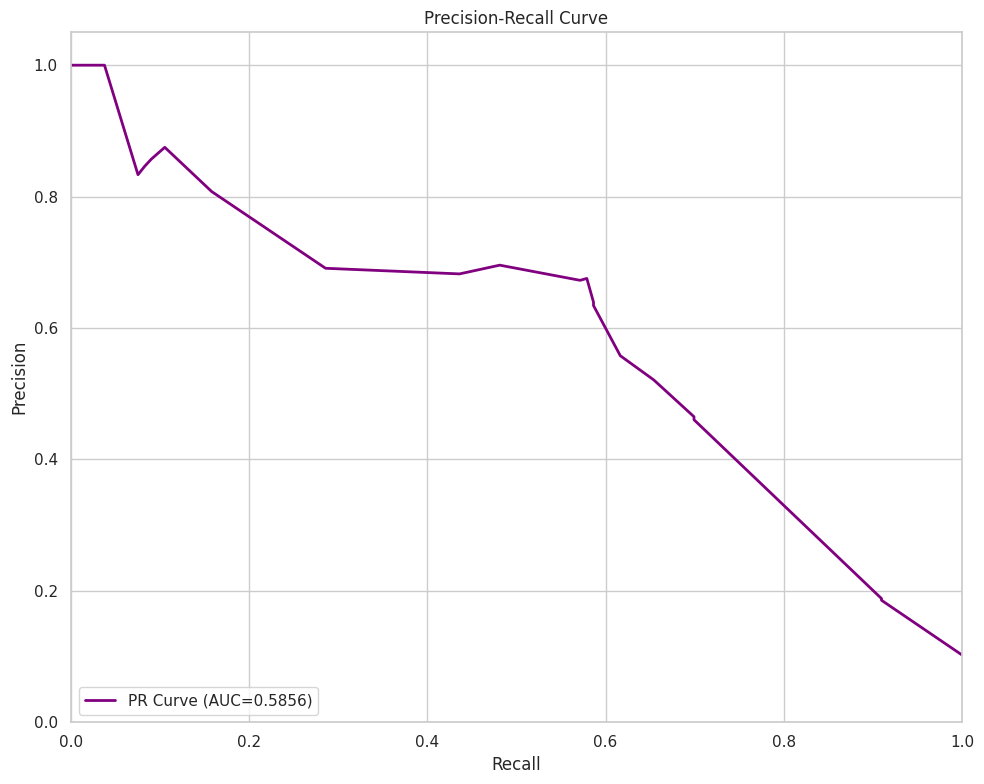

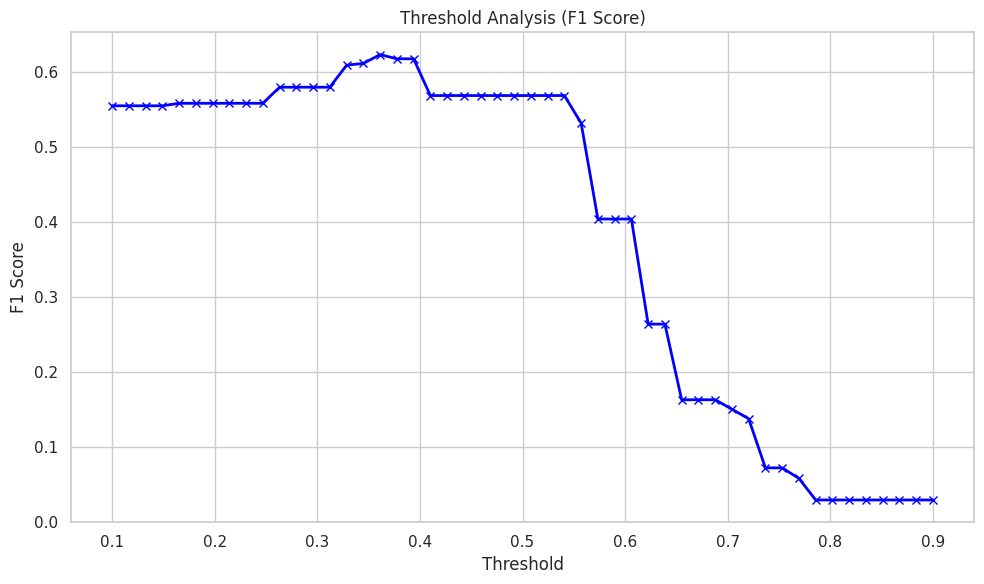

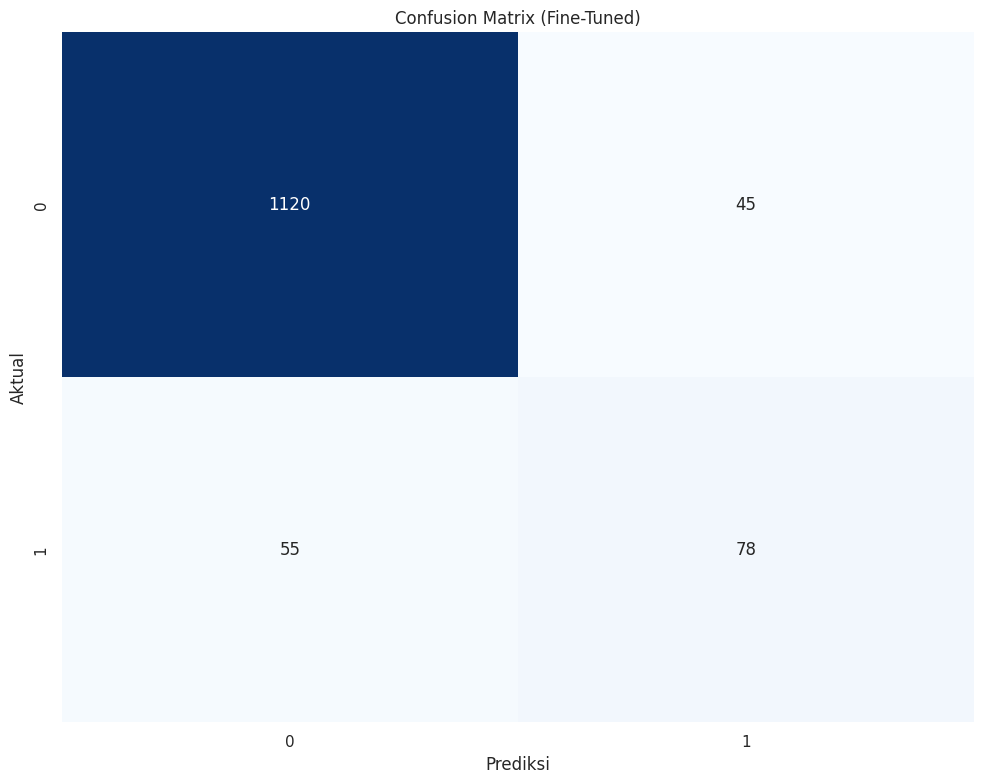

2026-07-18 22:24:36,823 - INFO - Menghitung metrik regresi...


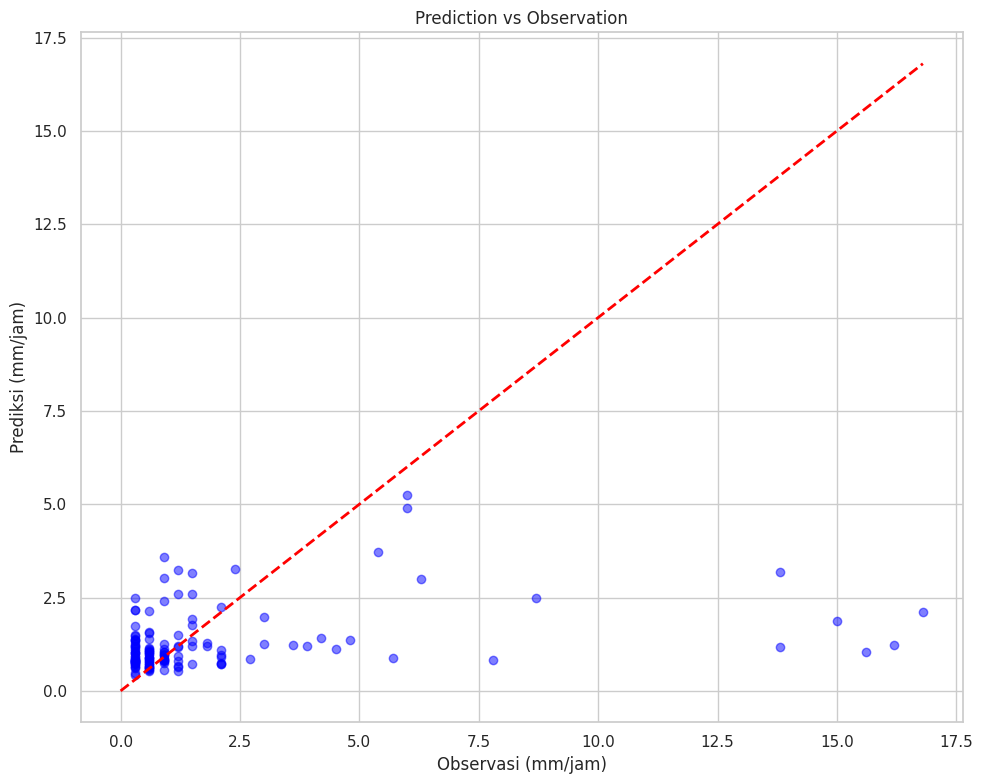

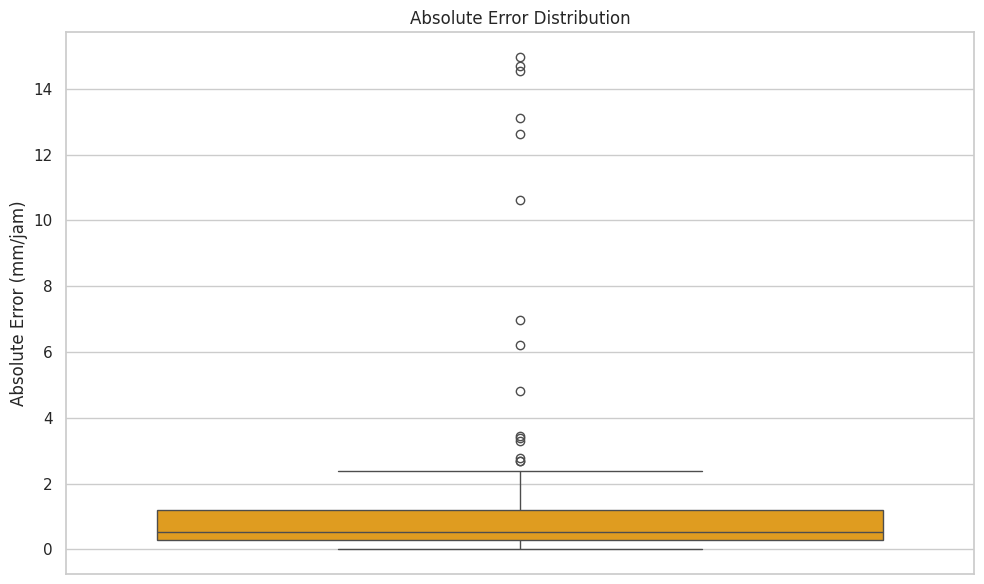

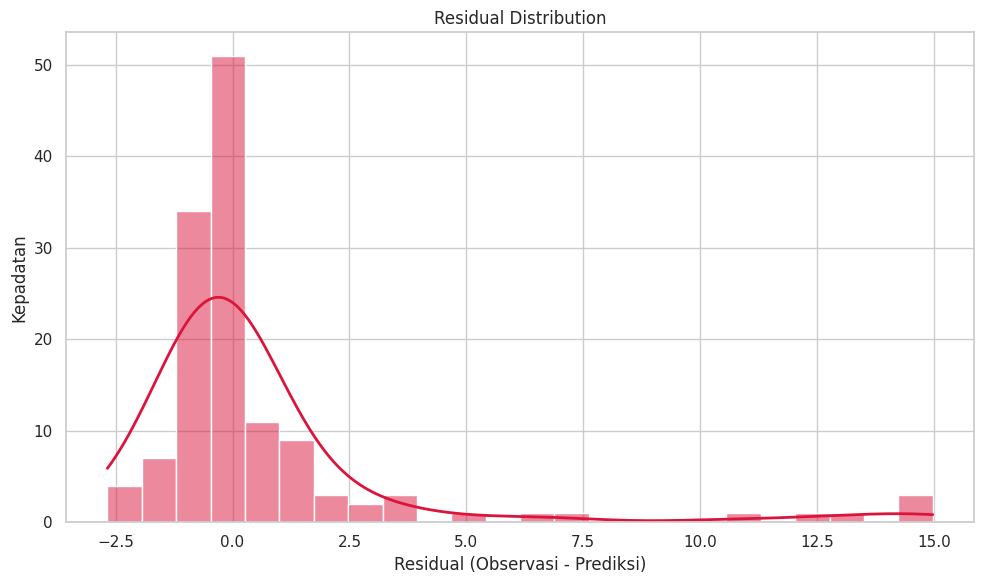

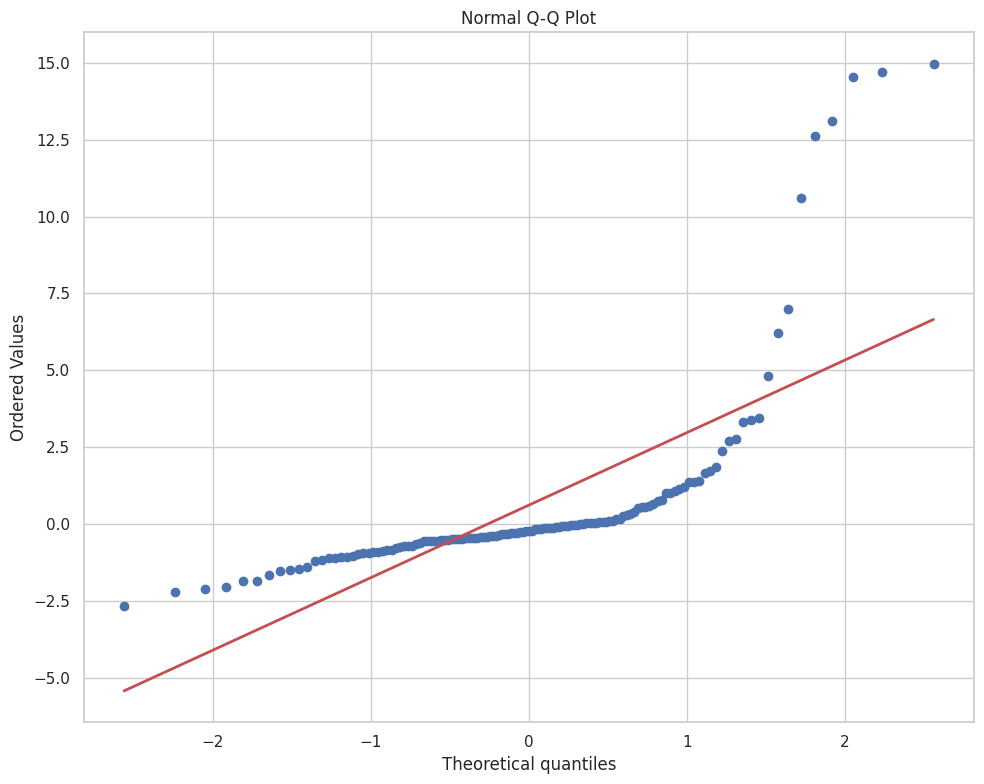

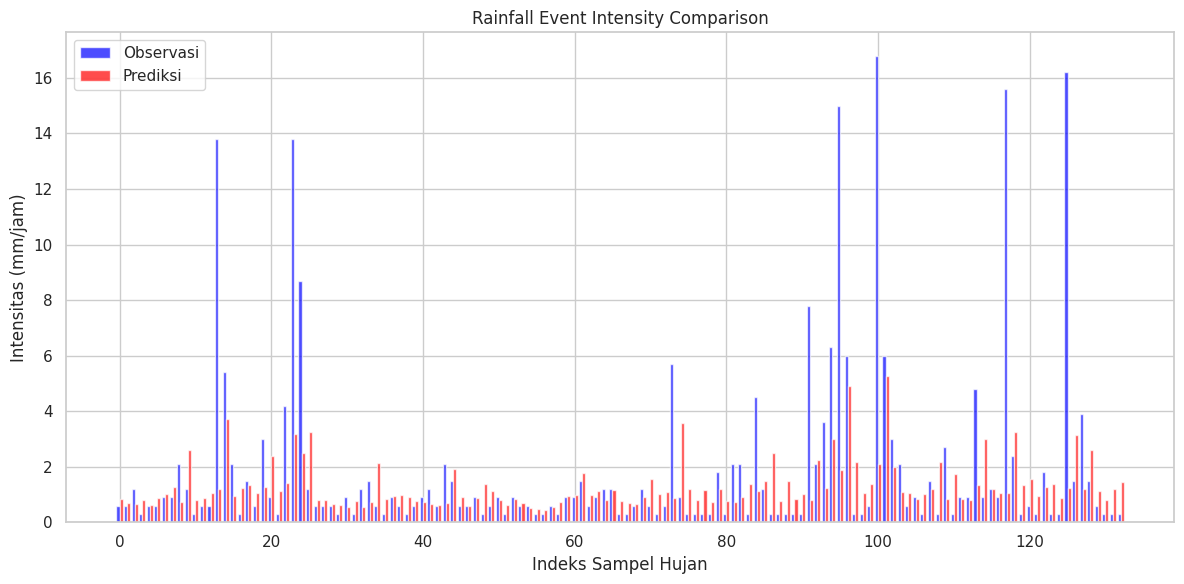

2026-07-18 22:24:40,191 - INFO - Evaluasi Model Fine-Tuned Selesai!


In [16]:
# Bab 2: Evaluasi Model Fine-Tuning (LSTM)
logger.info("Memulai Bab 2: Evaluasi Model Fine-Tuning...")
evaluator_ft = ModelEvaluator(BASE_OUTPUT_DIR, phase='finetuning')

# Load model fine-tuned terbaik
clf_best_ft = tf.keras.models.load_model(evaluator_ft.dirs['models_clf'] / 'best_lstm_occ_finetuned.keras')
reg_best_ft = tf.keras.models.load_model(evaluator_ft.dirs['models_reg'] / 'best_lstm_reg_finetuned.keras') if (evaluator_ft.dirs['models_reg'] / 'best_lstm_reg_finetuned.keras').exists() else None
calibrator_ft = joblib.load(evaluator_ft.dirs['models_cal'] / 'isotonic_calibrator_finetuned.pkl')

# Load threshold optimal fine-tuning
_thresh_file_ft = evaluator_ft.dirs['models_clf'] / 'best_threshold_finetuned.pkl'
best_threshold_finetuned = joblib.load(_thresh_file_ft) if _thresh_file_ft.exists() else 0.5
logger.info(f"Threshold klasifikasi fine-tuning: {best_threshold_finetuned:.2f}")

# Prediksi Klasifikasi Fine-Tuned
test_probs_uncal = clf_best_ft.predict(X_te_seq, verbose=0).flatten()
test_probs_cal = apply_calibrator(calibrator_ft, cal_method_ft, test_probs_uncal)
test_preds_occ = (test_probs_cal >= best_threshold_finetuned).astype(int)

# Prediksi Regresi Fine-Tuned (Hanya pada sampel hujan)
rainy_te = y_te_o == 1
test_preds_r = np.zeros(len(y_te_o))
if reg_best_ft is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = np.clip(np.expm1(reg_best_ft.predict(X_te_seq[rainy_te], verbose=0).flatten()), 0, None)

# Jalankan Evaluasi Klasifikasi Fine-Tuned
clf_metrics_ft, meteo_metrics_ft = evaluator_ft.evaluate_classification(
    y_te_o, test_probs_uncal, test_probs_cal, test_preds_occ
)
ece_ft, mce_ft = compute_ece_mce(y_te_o, test_probs_cal)
clf_metrics_ft['ECE'] = ece_ft
clf_metrics_ft['MCE'] = mce_ft
evaluator_ft.save_combined_metrics()

# Simpan Confusion Matrix Fine-Tuned
evaluator_ft.plot_confusion_matrix(y_te_o, test_preds_occ, filename='confusion_matrix.png', suffix='(Fine-Tuned)')

# Jalankan Evaluasi Regresi Fine-Tuned
if np.sum(rainy_te) > 0:
    reg_metrics_ft = evaluator_ft.evaluate_regression(y_te_r[rainy_te], test_preds_r[rainy_te])
else:
    reg_metrics_ft = {}

# Buat Laporan Evaluasi Fine-Tuned
evaluator_ft.generate_report(len(X_tr_seq), len(X_v_seq), len(X_te_seq), list(scaler.feature_names_in_), clf_metrics_ft, meteo_metrics_ft, reg_metrics_ft, "LSTM (Fine-Tuned)")
logger.info("Evaluasi Model Fine-Tuned Selesai!")


# Bab 3: Perbandingan Model Pretraining vs Fine-Tuning
Dalam bab ini, dilakukan pembandingan kurva evaluasi dan prediksi curah hujan LSTM dari kedua model (Pre-Trained vs Fine-Tuned) terhadap data aktual AWS bumi secara langsung.
